In [3]:
# KMeans Clustering on Iris Dataset
import numpy as np

np.random.seed(1)
from sklearn import cluster, datasets

X_iris, y_iris = datasets.load_iris(return_X_y=True)

k_means = cluster.KMeans(n_clusters=3)
k_means.fit(X_iris)
print(k_means.labels_[::10])
print(y_iris[::10])

[1 1 1 1 1 2 0 0 0 0 2 2 2 2 2]
[0 0 0 0 0 1 1 1 1 1 2 2 2 2 2]


[ 15.5625  46.6875  77.8125 108.9375 140.0625 171.1875 202.3125 233.4375]
[ 18.90934343  53.33478066  82.59678424 109.22385188 134.67876527
 159.67877978 184.72384803 223.17132867]


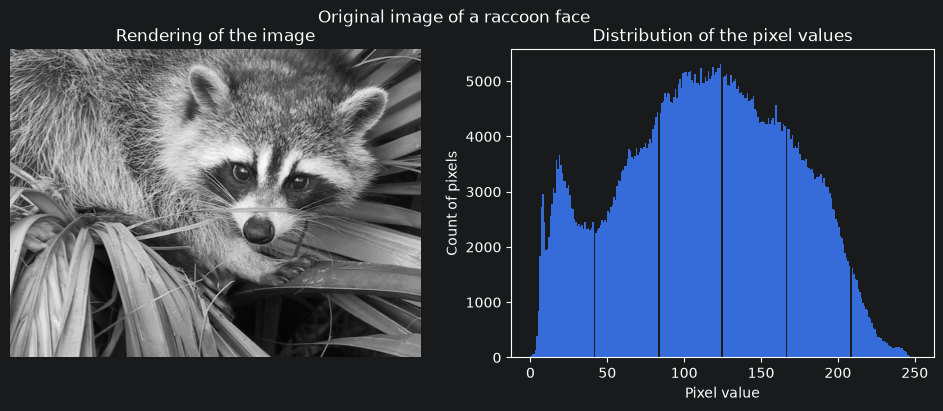

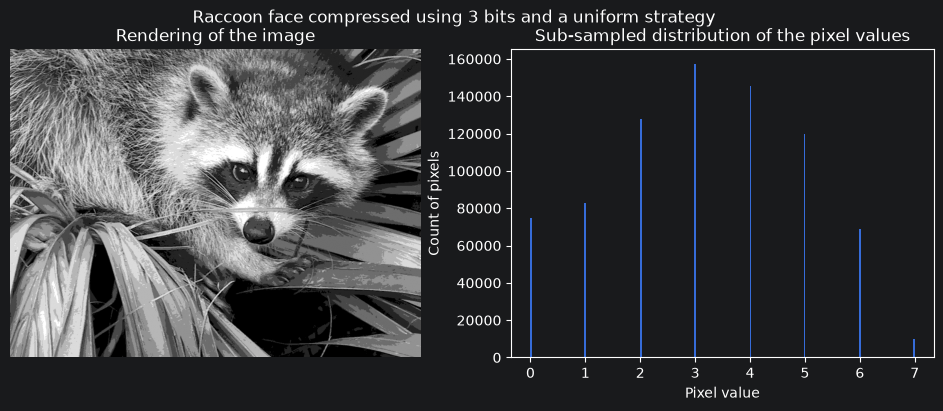

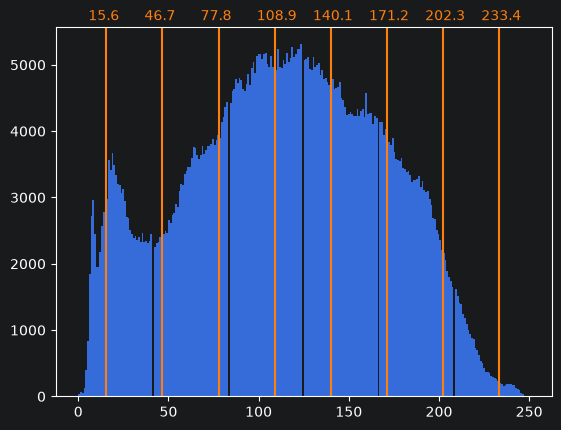

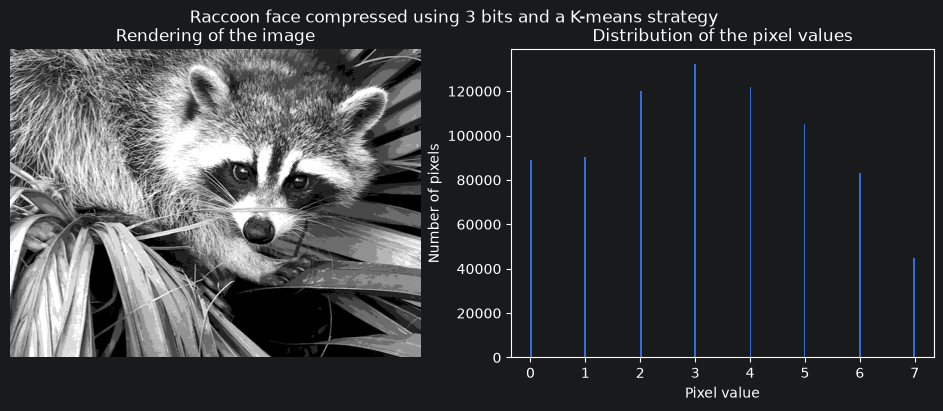

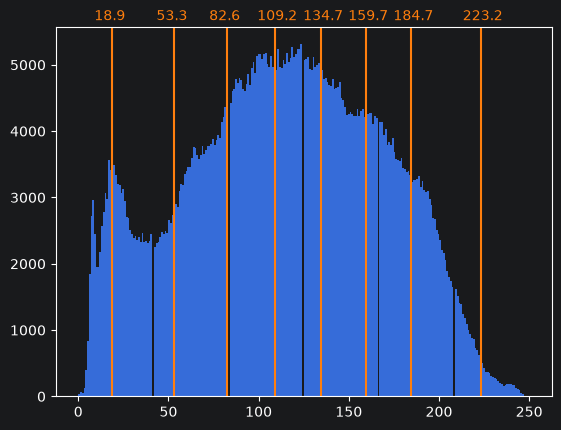

In [35]:
# KMeans Vector Quantization on Raccoon Face
import numpy as np
np.random.seed(1)
from sklearn import cluster
import scipy as sp
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer

try:
    face = sp.face(gray=True)
except:
    from scipy import datasets # scipy.misc deprecated, use datasets instead
    face = datasets.face(gray=True)
X = face.reshape((-1, 1)) # Need (n_sample, n_feature) array
k_means = cluster.KMeans(n_clusters=5, n_init=1)
k_means.fit(X)

values = k_means.cluster_centers_.squeeze()
labels = k_means.labels_
face_compressed = np.choose(labels, values)
face_compressed.reshape(face.shape)


fig, ax = plt.subplots(ncols=2, figsize=(12, 4))

ax[0].imshow(face, cmap=plt.cm.gray)
ax[0].axis("off")
ax[0].set_title("Rendering of the image")
ax[1].hist(face.ravel(), bins=256)
ax[1].set_xlabel("Pixel value")
ax[1].set_ylabel("Count of pixels")
ax[1].set_title("Distribution of the pixel values")
_ = fig.suptitle("Original image of a raccoon face")


n_bins = 8
encoder = KBinsDiscretizer(n_bins=n_bins,
                           encode="ordinal",
                           strategy="uniform",
                           random_state=0,
                           subsample=200_000,)
compressed_raccoon_uniform = encoder.fit_transform(face.reshape(-1, 1)).reshape(face.shape)

fig, ax = plt.subplots(ncols=2, figsize=(12, 4))
ax[0].imshow(compressed_raccoon_uniform, cmap=plt.cm.gray)
ax[0].axis("off")
ax[0].set_title("Rendering of the image")
ax[1].hist(compressed_raccoon_uniform.ravel(), bins=256)
ax[1].set_xlabel("Pixel value")
ax[1].set_ylabel("Count of pixels")
ax[1].set_title("Sub-sampled distribution of the pixel values")
_ = fig.suptitle("Raccoon face compressed using 3 bits and a uniform strategy")

bin_edges = encoder.bin_edges_[0]
bin_center = bin_edges[:-1] + (bin_edges[1:] - bin_edges[:-1]) / 2
print(bin_center)

_, ax = plt.subplots()
ax.hist(face.ravel(), bins=256)
color = "tab:orange"
for center in bin_center:
    ax.axvline(center, color=color)
    ax.text(center - 10, ax.get_ybound()[1] + 100, f"{center:.1f}", color=color)


encoder = KBinsDiscretizer(
    n_bins=n_bins,
    encode="ordinal",
    strategy="kmeans",
    random_state=0,
    subsample=200_000,
)
compressed_raccoon_kmeans = encoder.fit_transform(face.reshape(-1, 1)).reshape(face.shape)

fig, ax = plt.subplots(ncols=2, figsize=(12, 4))
ax[0].imshow(compressed_raccoon_kmeans, cmap=plt.cm.gray)
ax[0].axis("off")
ax[0].set_title("Rendering of the image")
ax[1].hist(compressed_raccoon_kmeans.ravel(), bins=256)
ax[1].set_xlabel("Pixel value")
ax[1].set_ylabel("Number of pixels")
ax[1].set_title("Distribution of the pixel values")
_ = fig.suptitle("Raccoon face compressed using 3 bits and a K-means strategy")

bin_edges = encoder.bin_edges_[0]
bin_center = bin_edges[:-1] + (bin_edges[1:] - bin_edges[:-1]) / 2
print(bin_center)

_, ax = plt.subplots()
ax.hist(face.ravel(), bins=256)
color = "tab:orange"
for center in bin_center:
    ax.axvline(center, color=color)
    ax.text(center - 10, ax.get_ybound()[1] + 100, f"{center:.1f}", color=color)

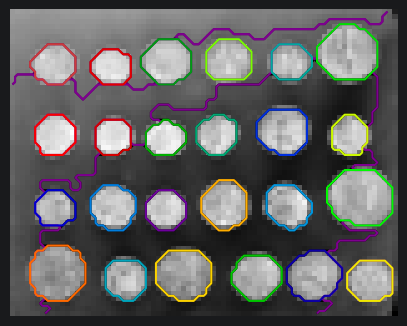

In [25]:
# Connectivity-Constrained Clustering on Coins
import numpy as np
np.random.seed(1)
from skimage.data import coins
from scipy.ndimage import gaussian_filter
from skimage.transform import rescale
from sklearn.feature_extraction import grid_to_graph
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

rescaled_coins = rescale(gaussian_filter(coins(), sigma=2), 0.2, mode='reflect', anti_aliasing=False)
X = np.reshape(rescaled_coins, (-1, 1))

connectivity = grid_to_graph(*rescaled_coins.shape)

n_clusters = 27 # number of regions
ward = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward', connectivity=connectivity)
ward.fit(X)
label = np.reshape(ward.labels_, rescaled_coins.shape)

plt.figure(figsize=(5, 5))
plt.imshow(rescaled_coins, cmap=plt.cm.gray)
for l in range(n_clusters):
    plt.contour(
        label == l,
        colors=[
            plt.cm.nipy_spectral(l / float(n_clusters)),
        ],
    )
plt.axis("off")
plt.show()

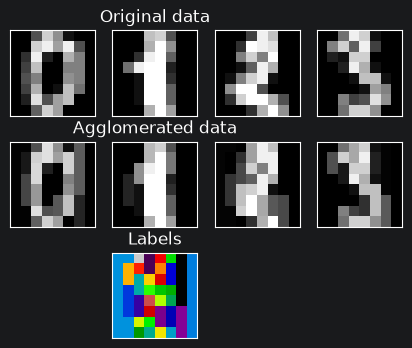

In [24]:
# Feature Agglomeration on Digits
import numpy as np
np.random.seed(1)
from sklearn import cluster, datasets
from sklearn.feature_extraction import grid_to_graph
import matplotlib.pyplot as plt

digits = datasets.load_digits()
images = digits.images
X = np.reshape(images, (len(images), -1))
connectivity = grid_to_graph(*images[0].shape)

agglo = cluster.FeatureAgglomeration(connectivity=connectivity, n_clusters=32)
agglo.fit(X)
X_reduced = agglo.transform(X)

X_restored = agglo.inverse_transform(X_reduced)
images_restored = np.reshape(X_restored, images.shape)

plt.figure(1, figsize=(4, 3.5))
plt.clf()
plt.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.91)
for i in range(4):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i], cmap=plt.cm.gray, vmax=16, interpolation="nearest")
    plt.xticks(())
    plt.yticks(())
    if i == 1:
        plt.title("Original data")
    plt.subplot(3, 4, 4 + i + 1)
    plt.imshow(images_restored[i], cmap=plt.cm.gray, vmax=16, interpolation="nearest")
    if i == 1:
        plt.title("Agglomerated data")
    plt.xticks(())
    plt.yticks(())

plt.subplot(3, 4, 10)
plt.imshow(
    np.reshape(agglo.labels_, images[0].shape),
    interpolation="nearest",
    cmap=plt.cm.nipy_spectral,
)
plt.xticks(())
plt.yticks(())
plt.title("Labels")
plt.show()

[2.7325821  0.75607076 0.        ]


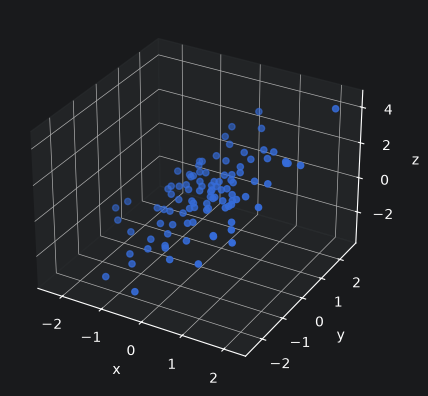

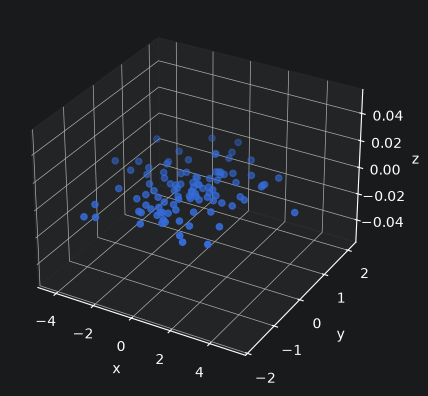

In [22]:
# PCA Decomposition
import numpy as np
np.random.seed(1)
import matplotlib.pyplot as plt
from sklearn import decomposition

x1 = np.random.normal(size=(100, 1))
x2 = np.random.normal(size=(100, 1))
x3 = x1 + x2
X = np.concatenate([x1, x2, x3], axis=1)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2])
_ = ax.set(xlabel='x', ylabel='y', zlabel='z')

pca = decomposition.PCA()
pca.fit(X)
print(pca.explained_variance_)

pca.set_params(n_components=2)
X_reduced=pca.fit_transform(X)
X_reduced.shape
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_reduced[:, 0], X_reduced[:, 1])
_ = ax.set(xlabel='x', ylabel='y', zlabel='z')

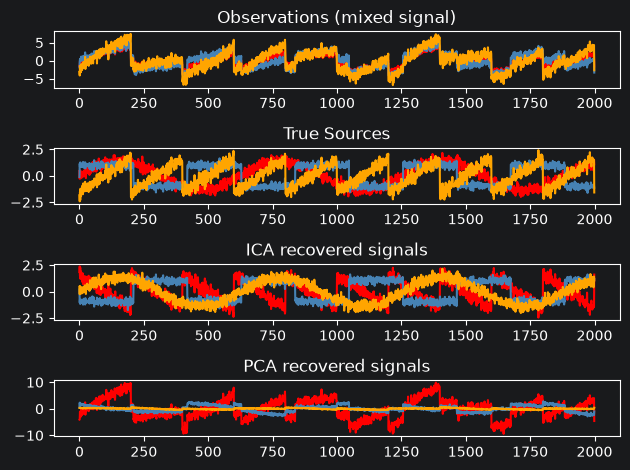

In [20]:
# ICA Decomposition
import numpy as np
np.random.seed(1)
import matplotlib.pyplot as plt
from sklearn import decomposition
from scipy import signal

time = np.linspace(0, 10, 2000)
s1 = np.sin(2*time) # Signal 1: sinusoidal signal
s2 = np.sign(np.sin(3 * time)) # Signal 2: square signal
s3 = signal.sawtooth(2 * np.pi * time) # Signal 3: saw tooth signal

S = np.c_[s1, s2, s3]
S += 0.2 * np.random.normal(size=S.shape) # Add noise
S /= S.std(axis=0) # Standardize data
# Mix data
A = np.array([[1, 1, 1], [0.5, 2, 1], [1.5, 1, 2]]) # Mixing matrix
X = np.dot(S, A.T) # Generate observations

# Compute ICA
ica = decomposition.FastICA()
S_ = ica.fit_transform(X) # Get estimated sources
A_ = ica.mixing_.T
np.allclose(X, np.dot(S_, A_) + ica.mean_)

# PCA for comparison
pca = decomposition.PCA(n_components=3)
H = pca.fit_transform(X) # Reconstruct signals

plt.figure()

models = [X, S, S_, H]
names = [
    "Observations (mixed signal)",
    "True Sources",
    "ICA recovered signals",
    "PCA recovered signals"
]
colors = ["red", "steelblue", "orange"]

for ii, (model, name) in enumerate(zip(models, names), 1):
    plt.subplot(4, 1, ii)
    plt.title(name)
    for sig, color in zip(model.T, colors):
        plt.plot(sig, color=color)

plt.tight_layout()
plt.show()